In [140]:

import sys
import os
import time
import numpy as np

import MDAnalysis as mda
# from MDAnalysis.analysis import align
# from MDAnalysis.analysis import distances

import westpa
from westpa.analysis import Run

import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
#this barely needs to be a method but having the .h5 stuff compartmentalized is nice
def load_h5_pcs(h5path, miniter, maxiter):
    
    run = Run.open(h5path)

    #set maximum iteration automatically
    if maxiter == -1:
        maxiter = run.num_iterations

    pcs = [iteration.pcoords for iteration in run if (iteration.number >= miniter and iteration.number < maxiter)]

    return pcs

In [158]:
#specify input file

cftr_west = "/home/jonathan/Documents/grabelab/cftr/chloe-data"
cftr_refpc = "/home/jonathan/Documents/grabelab/cftr/refeaturization"

h5paths_names = [[f"{cftr_west}/wstp_cftr_1_degrabo/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_1", "pyrazole-1", "blue"],
                  [f"{cftr_west}/wstp_cftr_2_wynton/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_2", "pyrazole-2", "cyan"],
                  [f"{cftr_west}/wstp_lip_glpg_1/west-040925.h5", f"{cftr_refpc}/lip_glpg_1", "undecanol-1", "red"],
                  [f"{cftr_west}/wstp_lip_glpg_2/west-040925.h5", f"{cftr_refpc}/lip_glpg_2", "undecanol-2", "orange"]]

#westpa rounds to load
minround = 0
maxround = -1

run_ind = 3

data_paths = ["/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1",
              "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-2",
              "/home/jonathan/Documents/grabelab/cftr/revisions/cftri-c10-1",
              "/home/jonathan/Documents/grabelab/cftr/revisions/cftri-c10-2"]
data_path = data_paths[run_ind]

final_rounds = [2000,1000,2000,2000]
final_round = final_rounds[run_ind]


In [159]:
pcs_all = load_h5_pcs(h5paths_names[run_ind][0], minround, maxround)

In [160]:
# nbins = 51
# binbounds = np.arange(0,nbins,1)
# bincenters = [(binbounds[i]+binbounds[i+1])/2 for i in range(len(binbounds)-1)]
# ligz_by_bin = [[] for a in range(nbins)]
#membrane_thickness_by_bin = [[] for a in range(nbins)]

pcs_all_processed = []
ligz_all = []
rounds_all = []
walkers_all = []

#later init_round values avoid questions about confounding time correlations but increase statistical noise
init_round = 0
#final_round = 1000
#loop over WE rounds
for r in range(init_round+1,final_round,10):
    
    #get progress coordinates of the walkers, accounting for the occasional corrupted file
    pcs_flat = pcs_all[r-1][:,-1].flatten()
    walkers = np.load(f"{data_path}/pc_data_round_{r}_walker_numbers_v1.npy")
    pcs = [pcs_flat[w] for w in walkers]

    #assign frames to bins by pc
    #bins = np.digitize(pcs, binbounds)

    #load water coordinates
    lig_coords = np.load(f"{data_path}/pc_data_round_{r}_ligand_pos_unaligned_v1.npy")

    if len(walkers) != len(lig_coords):
        print(f"upstream data processing error for round {r}")
        continue

    phos_z = np.load(f"{data_path}/pc_data_round_{r}_phosphate_z_means_v1.npy")

    #print(phos_z)
    #break

    ligz = np.mean(lig_coords[:,:,2], axis = 1)-(phos_z[:,2] + phos_z[:,3])/2

    pcs_all_processed += pcs
    ligz_all += list(ligz)
    rounds_all += [r for a in range(len(walkers))]
    walkers_all += list(walkers)

        #break

    # #get coordinates of waters in each bin
    # for b, lz in zip(bins, ligz):
    #     ligz_by_bin[b].append(lz)
    #     #membrane_thickness_by_bin[b].append(mem)

# for i, w in enumerate(ligz_by_bin):
#     print(f"{i}: {len(w)}")

# mean_boxdims_by_bin = np.stack([np.mean(np.stack(w), axis=0) if len(w) > 0 else -np.ones(6) for w in boxdims_by_bin])
# std_boxdims_by_bin = np.stack([np.std(np.stack(w), axis=0) if len(w) > 0 else np.zeros(6) for w in boxdims_by_bin])

# mean_membrane_thickness_by_bin = [np.mean(w) if len(w) > 0 else -1 for w in membrane_thickness_by_bin]
# std_membrane_thickness_by_bin = [np.std(w) if len(w) > 0 else 0 for w in membrane_thickness_by_bin]

report_extremes = False
if report_extremes:
    print(min(ligz_all))
    print(rounds_all[np.argmin(ligz_all)])
    print(walkers_all[np.argmin(ligz_all)])
    print(max(ligz_all))
    print(rounds_all[np.argmax(ligz_all)])
    print(walkers_all[np.argmax(ligz_all)])

upstream data processing error for round 1501
upstream data processing error for round 1711


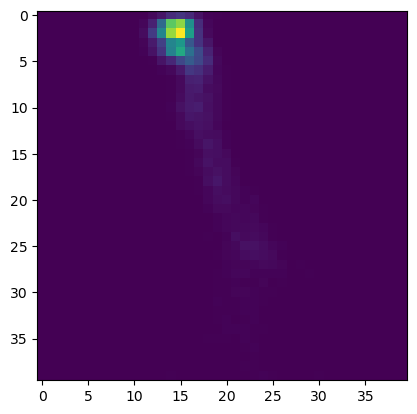

In [161]:
lig_z_pc_hist = np.histogramdd((pcs_all_processed, ligz_all), range=[[0, 40],[-20, 20]], bins = [40,40])
plt.imshow(lig_z_pc_hist[0], aspect="equal")

In [162]:
lig_z_pc_hist

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 [array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
         13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
         26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
         39., 40.]),
  array([-20., -19., -18., -17., -16., -15., -14., -13., -12., -11., -10.,
          -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
           2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,  12.,
          13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.])])

<Axes: xlabel='Ligand distance from bound pose (Å)', ylabel='Ligand z coordinate\nrelative to membrane center (Å)'>

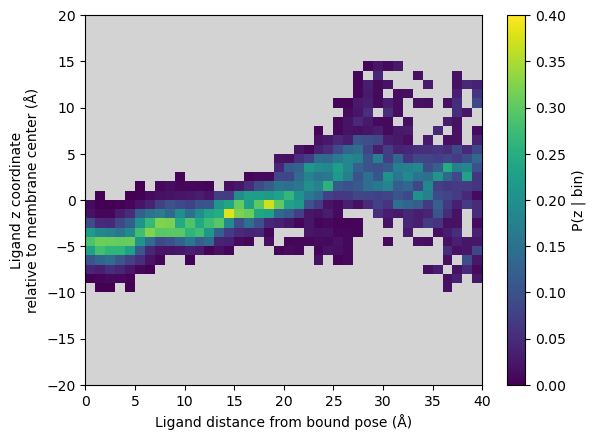

In [164]:
#write a python function which takes a matrix of histogram bin counts or densities and two 1d arrays with axis values as its arguments, 
# masks the matrix to show bins with zero count in grey, and plots a 2d histogram (as if from plt.hist2d) of the values

def plot_hist2d_from_matrix(H, xvals, yvals, ax=None, cmap="viridis"):
    """
    Plot a 2D histogram from a matrix of bin counts/densities, masking zeros in grey.

    Parameters
    ----------
    H : (ny, nx) array
        Matrix of histogram counts or densities.
    xvals : (nx+1) or (nx,) array
        Bin edges or bin centers along x.
    yvals : (ny+1) or (ny,) array
        Bin edges or bin centers along y.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (creates one if None).
    cmap : str or Colormap
        Colormap for nonzero bins.
    """

    H = np.asarray(H)

    # Mask zero bins
    Hmasked = np.ma.masked_where(H == 0, H)

    #needlessly general for my purposes
    if False:
        # If centers were provided, convert to edges
        def centers_to_edges(v):
            dv = np.diff(v)
            edges = np.empty(len(v) + 1)
            edges[1:-1] = v[:-1] + dv / 2
            edges[0] = v[0] - dv[0] / 2
            edges[-1] = v[-1] + dv[-1] / 2
            return edges

        if len(xvals) == H.shape[1]:
            xedges = centers_to_edges(xvals)
        else:
            xedges = xvals

        if len(yvals) == H.shape[0]:
            yedges = centers_to_edges(yvals)
        else:
            yedges = yvals

        

    if ax is None:
        fig, ax = plt.subplots()

    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("lightgrey")

    norm = mpl.colors.Normalize(vmin=0, vmax=0.4)

    mesh = ax.pcolormesh(xvals, yvals, Hmasked, cmap=cmap, norm=norm)
    plt.colorbar(mesh, ax=ax, label="P(z | bin)", norm=norm)#, boundaries=np.arange(0,1.1,0.1))

    ax.set_xlabel("Ligand distance from bound pose (Å)")
    ax.set_ylabel("Ligand z coordinate\nrelative to membrane center (Å)")

    return ax

#testing
lig_z_pc_hist = np.histogramdd((pcs_all_processed, ligz_all), range=[[0, 40],[-20, 20]], bins = [40,40])

bin_normalized_density = lig_z_pc_hist[0]/lig_z_pc_hist[0].sum(axis=1, keepdims=True)

plot_hist2d_from_matrix(bin_normalized_density.transpose(), lig_z_pc_hist[1][0], lig_z_pc_hist[1][1], ax=None, cmap="viridis")

In [128]:
np.arange(0,1.1,0.1)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

23516


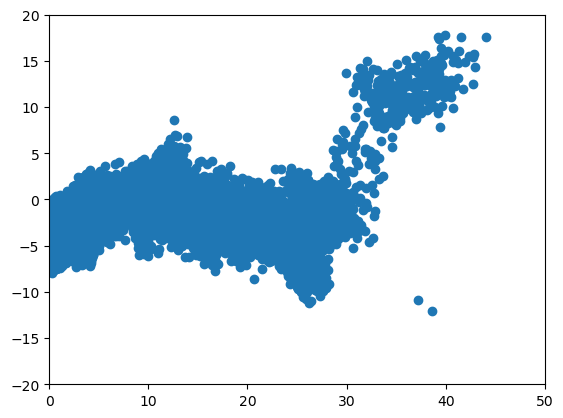

In [96]:
plt.scatter(pcs_all_processed, ligz_all)
plt.ylim(-20, 20)
plt.xlim(0, 50)
print(len(pcs_all_processed))

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([ 0. ,  0.8,  1.6,  2.4,  3.2,  4. ,  4.8,  5.6,  6.4,  7.2,  8. ,
         8.8,  9.6, 10.4, 11.2, 12. , 12.8, 13.6, 14.4, 15.2, 16. , 16.8,
        17.6, 18.4, 19.2, 20. , 20.8, 21.6, 22.4, 23.2, 24. , 24.8, 25.6,
        26.4, 27.2, 28. , 28.8, 29.6, 30.4, 31.2, 32. , 32.8, 33.6, 34.4,
        35.2, 36. , 36.8, 37.6, 38.4, 39.2, 40. ]),
 array([-20. , -19.2, -18.4, -17.6, -16.8, -16. , -15.2, -14.4, -13.6,
        -12.8, -12. , -11.2, -10.4,  -9.6,  -8.8,  -8. ,  -7.2,  -6.4,
         -5.6,  -4.8,  -4. ,  -3.2,  -2.4,  -1.6,  -0.8,   0. ,   0.8,
          1.6,   2.4,   3.2,   4. ,   4.8,   5.6,   6.4,   7.2,   8. ,
          8.8,   9.6,  10.4,  11.2,  12. ,  12.8,  13.6,  14.4,  15.2,
         16. ,  16.8,  17.6,  18.4,  19.2,  20. 

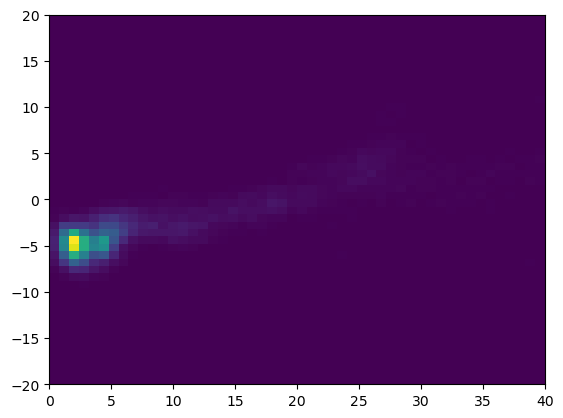

In [71]:
plt.hist2d(pcs_all_processed, ligz_all, range=[[0, 40],[-20, 20]], bins = [50,50])

(3.8, 4.1)

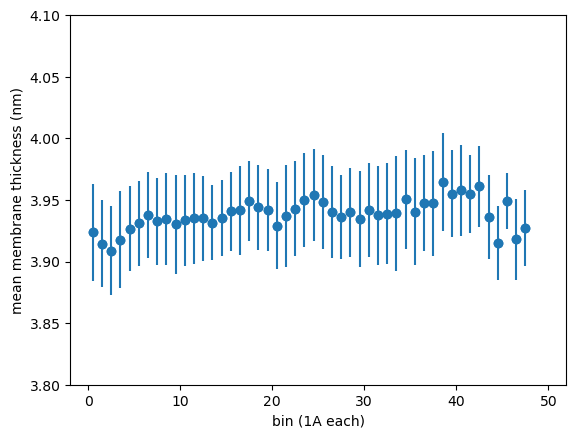

In [37]:
plt.scatter(bincenters, np.array(mean_membrane_thickness_by_bin[1:])/10)
plt.errorbar(bincenters, np.array(mean_membrane_thickness_by_bin[1:])/10, yerr=np.array(std_membrane_thickness_by_bin[1:])/10, fmt = "o")

plt.xlabel("bin (1A each)")
plt.ylabel("mean membrane thickness (nm)")
plt.ylim(3.8,4.1)

(10.1, 10.4)

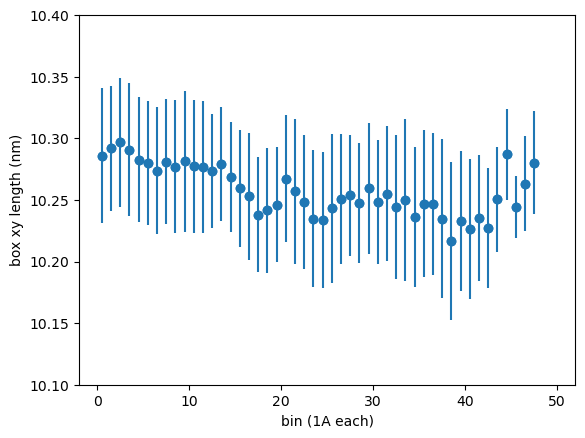

In [38]:
plt.scatter(bincenters, mean_boxdims_by_bin[1:,0]/10)
plt.errorbar(bincenters, mean_boxdims_by_bin[1:,0]/10, yerr=std_boxdims_by_bin[1:,0]/10, fmt = "o")

plt.xlabel("bin (1A each)")
plt.ylabel("box xy length (nm)")
plt.ylim(10.1,10.4)

Text(0.5, 0, 'bin (1A each)')

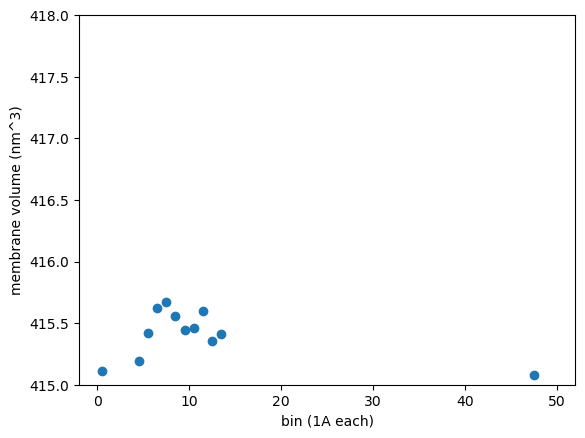

In [39]:
membrane_volume = np.product(np.stack([mean_boxdims_by_bin[1:,0], mean_boxdims_by_bin[1:,1], mean_membrane_thickness_by_bin[1:]]), axis = 0)
plt.scatter(bincenters, membrane_volume/1000)
plt.ylim(415, 418)
plt.ylabel("membrane volume (nm^3)")
plt.xlabel("bin (1A each)")
#to get more accurate values and error bars which properly reflected the width-thickness correlation would require going back to the frame-level data


Text(0, 0.5, 'box xy length (A)')

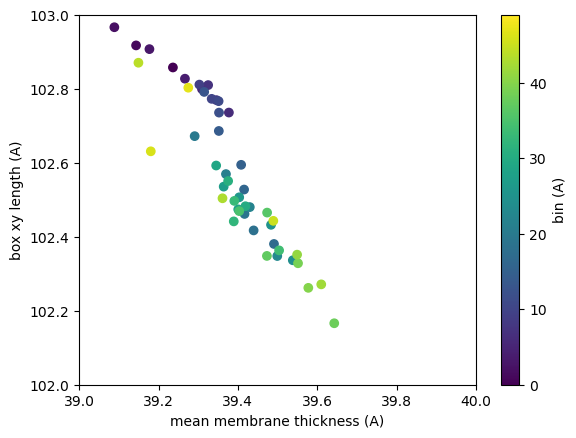

In [40]:
order_values = np.arange(len(mean_membrane_thickness_by_bin[1:]))

plt.scatter(mean_membrane_thickness_by_bin[1:], mean_boxdims_by_bin[1:,0], c = order_values)
plt.colorbar(label = "bin (A)")
plt.xlim(39,40)
plt.ylim(102,103)

plt.xlabel("mean membrane thickness (A)")
plt.ylabel("box xy length (A)")


In [80]:
def plot_to_subplot(data_path, h5path, final_round, axs, col):

    pcs_all = load_h5_pcs(h5path, minround, maxround)
    
    nbins = 51
    binbounds = np.arange(0,nbins,1)
    bincenters = [(binbounds[i]+binbounds[i+1])/2 for i in range(len(binbounds)-1)]
    boxdims_by_bin = [[] for a in range(nbins)]
    membrane_thickness_by_bin = [[] for a in range(nbins)]

    #later init_round values avoid questions about confounding time correlations but increase statistical noise
    init_round = 0
    #loop over WE rounds
    for r in range(init_round+1,final_round,10):
        
        #get progress coordinates of the walkers, accounting for the occasional corrupted file
        pcs_flat = pcs_all[r-1][:,-1].flatten()
        walkers = np.load(f"{data_path}/pc_data_round_{r}_walker_numbers_v1.npy")
        pcs = [pcs_flat[w] for w in walkers]

        #assign frames to bins by pc
        bins = np.digitize(pcs, binbounds)

        #load water coordinates
        boxdims = np.load(f"{data_path}/pc_data_round_{r}_boxdims_v1.npy")
        membrane_thickness = np.load(f"{data_path}/pc_data_round_{r}_membrane_thickness_v1.npy")

        #get coordinates of waters in each bin
        for b, box, mem in zip(bins, boxdims, membrane_thickness):
            boxdims_by_bin[b].append(box)
            membrane_thickness_by_bin[b].append(mem)

    for i, w in enumerate(boxdims_by_bin):
        print(f"{i}: {len(w)}")

    mean_boxdims_by_bin = np.stack([np.mean(np.stack(w), axis=0) if len(w) > 0 else -np.ones(6) for w in boxdims_by_bin])
    std_boxdims_by_bin = np.stack([np.std(np.stack(w), axis=0) if len(w) > 0 else np.zeros(6) for w in boxdims_by_bin])

    mean_membrane_thickness_by_bin = [np.mean(w) if len(w) > 0 else -1 for w in membrane_thickness_by_bin]
    std_membrane_thickness_by_bin = [np.std(w) if len(w) > 0 else 0 for w in membrane_thickness_by_bin]

    axs[(0,col)].scatter(bincenters, np.array(mean_membrane_thickness_by_bin[1:]))
    axs[(0,col)].errorbar(bincenters, np.array(mean_membrane_thickness_by_bin[1:]), yerr=np.array(std_membrane_thickness_by_bin[1:]), fmt = "o")
    axs[(0,col)].set_ylim(38,41)
    axs[(0,col)].set_xlim(0,40)
    
    axs[(1,col)].scatter(bincenters, mean_boxdims_by_bin[1:,0])
    axs[(1,col)].errorbar(bincenters, mean_boxdims_by_bin[1:,0], yerr=std_boxdims_by_bin[1:,0], fmt = "o")
    axs[(1,col)].set_xlim(0,40)
    axs[(1,col)].set_ylim(100,105)

    if col == 0:
        axs[0,0].set_ylabel("Membrane thickness (Å)") #r"Membrane thickness ($\AA$)")
        axs[1,0].set_ylabel("Box xy length (Å)") #r"Box xy length ($\AA$)")

    title_elements = data_path.split("/")[-1].split("-")
    if title_elements[0] == "abbv":
        ti0 = "ABBV"
    elif title_elements[0] == "cftri":
        ti0 = "CFTRi"


    axs[(1,col)].set_xlabel(f"Ligand distance from bound pose (Å) \n {ti0}-{title_elements[1].upper()} run {title_elements[2]}")


0: 0
1: 2791
2: 3366
3: 2900
4: 2488
5: 2568
6: 942
7: 645
8: 675
9: 669
10: 678
11: 671
12: 579
13: 375
14: 189
15: 152
16: 311
17: 437
18: 324
19: 369
20: 317
21: 235
22: 159
23: 204
24: 224
25: 281
26: 348
27: 245
28: 111
29: 129
30: 100
31: 47
32: 43
33: 37
34: 31
35: 37
36: 44
37: 33
38: 41
39: 35
40: 36
41: 15
42: 9
43: 7
44: 0
45: 1
46: 0
47: 0
48: 0
49: 0
50: 0
0: 0
1: 1343
2: 1401
3: 1313
4: 1113
5: 1104
6: 447
7: 240
8: 290
9: 278
10: 259
11: 318
12: 267
13: 168
14: 95
15: 60
16: 112
17: 176
18: 217
19: 186
20: 166
21: 139
22: 137
23: 160
24: 149
25: 176
26: 292
27: 259
28: 164
29: 142
30: 143
31: 91
32: 51
33: 70
34: 72
35: 67
36: 69
37: 71
38: 66
39: 77
40: 54
41: 57
42: 31
43: 13
44: 1
45: 0
46: 0
47: 0
48: 0
49: 0
50: 0
0: 0
1: 2035
2: 2935
3: 1436
4: 476
5: 439
6: 220
7: 242
8: 194
9: 160
10: 237
11: 218
12: 195
13: 116
14: 69
15: 88
16: 235
17: 236
18: 214
19: 227
20: 265
21: 301
22: 247
23: 133
24: 49
25: 71
26: 64
27: 42
28: 30
29: 16
30: 21
31: 18
32: 14
33: 6
34: 19

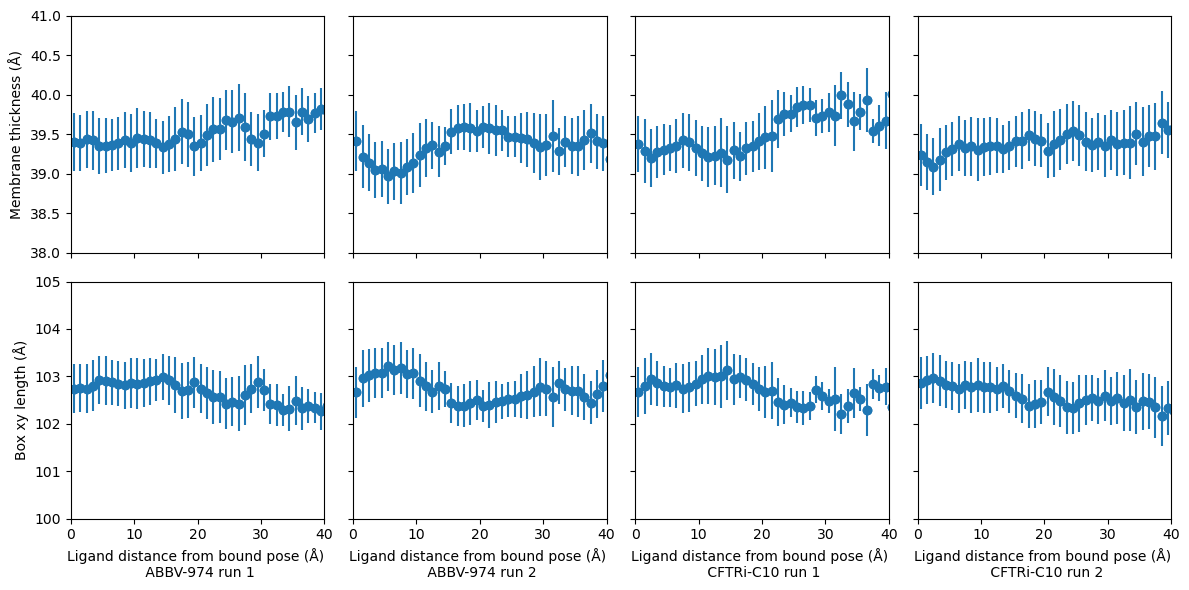

In [81]:
fig, axs = plt.subplots(2, 4, sharex='col', sharey='row', figsize=(12, 6))

maxrounds = [2000,1000,2000,2000]
for run_ind in range(4):
    # x = run_ind%2
    # y = run_ind//2
    data_path = data_paths[run_ind]
    h5path = h5paths_names[run_ind][0]
    plot_to_subplot(data_path, h5path, maxrounds[run_ind], axs, run_ind)

plt.tight_layout()
plt.savefig("/home/jonathan/Documents/grabelab/cftr/revisions/membrane_dimensions.svg", format="svg", bbox_inches="tight")